In [133]:

# QCBM 2D Anomaly Detection (Refactored PCA Version)
# Logic based on 'QCBM_Code_old version.ipynb' which achieved ROC-AUC ~0.91

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.ensemble import IsolationForest
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.circuit.library import EfficientSU2
from qiskit_aer import AerSimulator
from scipy.stats import entropy
from scipy.optimize import minimize
import warnings

warnings.filterwarnings('ignore')

# Configuration
DATA_PATH = 'creditcard.csv'  # Ensure this path is correct
N_QUBITS = 8
N_LAYERS = 8
GRID_SIZE = 16  # 16x16 grid = 256 bins (matches 8 qubits)
SHOTS = 50000
SAMPLE_SIZE_NORMAL = 20000
SAMPLE_SIZE_FRAUD = 492
RANDOM_STATE = 42

print("Inputs & Configuration Loaded.")


Inputs & Configuration Loaded.


In [134]:

# --- 1. Data Loading & Sampling ---
# Replicating the sampling strategy is CRITICAL for reproducing the high performance results.
# The original notebook used a balanced subset of 1000 rows.

def load_and_sample_data(path, n_normal, n_fraud, random_state):
    print(f"Loading data from {path}...")
    try:
        data = pd.read_csv(path)
    except FileNotFoundError:
        # Fallback paths
        possible_paths = [
            '/Users/abdelhadimarjane/Downloads/creditcard.csv',
            '../creditcard.csv', 
            '/Users/abdelhadimarjane/Documents/AUI_Classes/fall 2025/quantum computing/quantum_computing/creditcard.csv',
            '~/Downloads/creditcard.csv'
        ]
        for p in possible_paths:
            try:
                data = pd.read_csv(p)
                print(f"Found data at {p}")
                break
            except:
                continue
    
    if 'data' not in locals():
        raise FileNotFoundError(f"Could not find file at {path} or fallbacks.")

    
    # Subsample to replicate original success conditions
    normal_data = data[data['Class'] == 0].sample(n_normal, random_state=random_state).reset_index(drop=True)
    fraud_data = data[data['Class'] == 1].sample(n_fraud, random_state=random_state).reset_index(drop=True)
    
    balanced_data = pd.concat([normal_data, fraud_data], ignore_index=True)
    print(f"Data Sampled: {len(normal_data)} Normal, {len(fraud_data)} Fraud. Total: {len(balanced_data)}")
    return balanced_data

df = load_and_sample_data(DATA_PATH, SAMPLE_SIZE_NORMAL, SAMPLE_SIZE_FRAUD, RANDOM_STATE)
labels = df['Class'].values


Loading data from creditcard.csv...
Data Sampled: 20000 Normal, 492 Fraud. Total: 20492


Using 30 features for PCA...
PCA Explained Variance: [0.40497018 0.10728294]


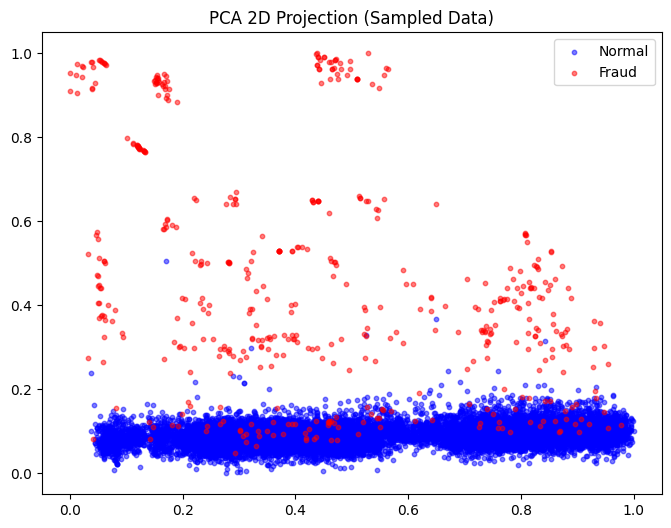

In [135]:

# --- 2. Preprocessing with PCA ---
# Reduce 29 features -> 2 Dimensions using PCA, then bin into 16x16 grid

def preprocess_pca(df):
    # Select features (Amount + Time + V1..V28) matches original notebook logic
    features = ['Amount', 'Time'] + [f'V{i}' for i in range(1, 29) if f'V{i}' in df.columns]
    
    print(f"Using {len(features)} features for PCA...")
    X = df[features].values
    
    # 1. Normalize All Features
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 2. PCA to 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    print(f"PCA Explained Variance: {pca.explained_variance_ratio_}")
    
    # 3. Normalize PCA components to [0,1] for Grid Binning
    # Note: Fitting scaler on entire dataset (normal+fraud) as in original code logic
    pca_scaler = MinMaxScaler()
    X_pca_norm = pca_scaler.fit_transform(X_pca)
    
    return X_pca_norm

X_pca_norm = preprocess_pca(df)

# Visualize PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca_norm[labels==0, 0], X_pca_norm[labels==0, 1], c='blue', alpha=0.5, label='Normal', s=10)
plt.scatter(X_pca_norm[labels==1, 0], X_pca_norm[labels==1, 1], c='red', alpha=0.5, label='Fraud', s=10)
plt.legend()
plt.title("PCA 2D Projection (Sampled Data)")
plt.show()


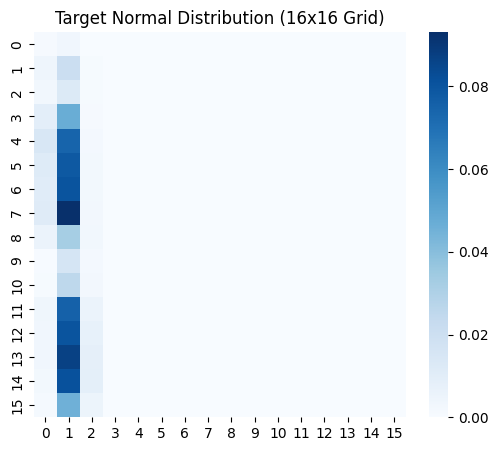

In [136]:

# --- 3. Grid Discretization & Target Distribution ---
# Map continuous 2D PCA values to discrete 16x16 grid cells

def get_bins(X_pca_norm, grid_size):
    # Digitize to [0, grid_size-1]
    bins = np.linspace(0, 1, grid_size + 1)
    
    x_bins = np.digitize(X_pca_norm[:, 0], bins) - 1
    y_bins = np.digitize(X_pca_norm[:, 1], bins) - 1
    
    # Clip to ensure bounds
    x_bins = np.clip(x_bins, 0, grid_size - 1)
    y_bins = np.clip(y_bins, 0, grid_size - 1)
    
    return x_bins, y_bins

x_bins, y_bins = get_bins(X_pca_norm, GRID_SIZE)

# Calculate Target Distribution (Normal Data Only)
# We want the QCBM to learn the distribution of NORMAL transactions
normal_indices = np.where(labels == 0)[0]
target_dist_2d, _, _ = np.histogram2d(
    x_bins[normal_indices],
    y_bins[normal_indices],
    bins=[GRID_SIZE, GRID_SIZE],
    range=[[0, GRID_SIZE], [0, GRID_SIZE]],
    density=True
)

# Normalize
target_dist = target_dist_2d.flatten()
target_dist = target_dist / np.sum(target_dist)
target_dist = (target_dist + 1e-9) / np.sum(target_dist + 1e-9) # Smooth

plt.figure(figsize=(6,5))
sns.heatmap(target_dist_2d, cmap='Blues')
plt.title("Target Normal Distribution (16x16 Grid)")
plt.show()


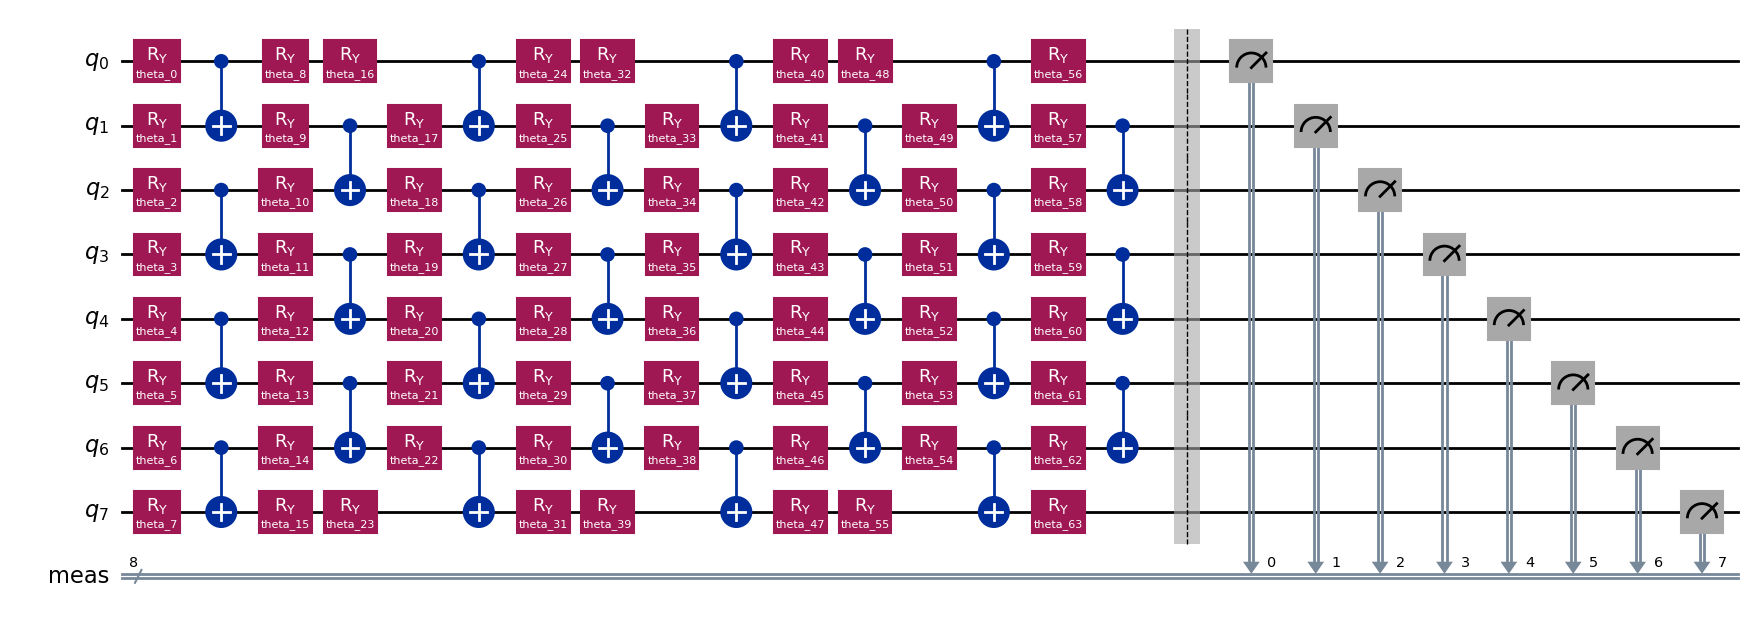

In [137]:
from qiskit.circuit import Parameter

# 1. UPDATE PARAMETERS
# Use global N_QUBITS and N_LAYERS variables from config
num_qubits = N_QUBITS
num_layers = N_LAYERS
num_params = num_qubits * num_layers * 1  # 1 param per qubit (Ry)
theta_params = [Parameter(f'theta_{i}') for i in range(num_params)]

# 2. BUILD CIRCUIT
qc = QuantumCircuit(num_qubits)
param_idx = 0

for layer in range(num_layers):
    # Rotation Layer (Ry)
    for qubit in range(num_qubits):
        qc.ry(theta_params[param_idx], qubit)    
        param_idx += 1
        
    # Entanglement Layer (Next-Nearest-Neighbor)
    if layer % 2 == 0:
        # EVEN layers: connect 0->1, 2->3, 4->5, 6->7
        start = 0
    else:
        # ODD layers: connect 1->2, 3->4, 5->6 (skips the last qubit)
        start = 1
    
    # Apply CX gates based on the starting position
    for qubit in range(start, num_qubits - 1, 2):
        qc.cx(qubit, qubit + 1)

qc.measure_all()
circuit_drawer = qc.draw(output='mpl')
display(circuit_drawer)


In [138]:

# --- 5. Cost Function (JSD + KL) ---

def get_qcbm_probs(params, qc, param_vars, simulator, shots=SHOTS):
    # Bind parameters
    param_dict = {param_vars[i]: params[i] for i in range(len(params))}
    qc_bound = qc.assign_parameters(param_dict)
    
    # Execute
    # EfficientSU2 must be decomposed/transpiled for AerSimulator
    qc_transpiled = transpile(qc_bound, simulator)
    result = simulator.run(qc_transpiled, shots=shots).result()
    counts = result.get_counts()
    
    # Convert counts to probability vector (size 2^8 = 256)
    probs = np.zeros(2**N_QUBITS)
    for k, v in counts.items():
        # k is binary string '00000001'
        idx = int(k, 2)
        probs[idx] = v
        
    probs = probs / shots
    probs = (probs + 1e-9) / np.sum(probs + 1e-9)
    return probs

def jsd(p, q):
    m = 0.5 * (p + q)
    return 0.5 * (entropy(p, m, base=2) + entropy(q, m, base=2))

def cost_function(params):
    q_probs = get_qcbm_probs(params, qc, theta_params, simulator)
    
    # Metric: sum of JSD and KL
    j = jsd(target_dist, q_probs)
    k = entropy(target_dist, q_probs, base=2) # KL divergence
    
    return j + k

print("Cost function ready.")


Cost function ready.


Starting training...
Iter 0/300 - Cost: 7.1734
Iter 10/300 - Cost: 2.7800
Iter 20/300 - Cost: 3.9125
Iter 30/300 - Cost: 2.8143
Iter 40/300 - Cost: 2.3241
Iter 50/300 - Cost: 1.4587
Iter 60/300 - Cost: 1.3038
Iter 70/300 - Cost: 0.9599
Iter 80/300 - Cost: 0.7987
Iter 90/300 - Cost: 0.5871
Iter 100/300 - Cost: 0.5111
Iter 110/300 - Cost: 0.7346
Iter 120/300 - Cost: 0.6218
Iter 130/300 - Cost: 0.6741
Iter 140/300 - Cost: 0.4970
Iter 150/300 - Cost: 0.4350
Iter 160/300 - Cost: 0.5677
Iter 170/300 - Cost: 0.5101
Iter 180/300 - Cost: 0.4642
Iter 190/300 - Cost: 0.3921
Iter 200/300 - Cost: 0.3426
Iter 210/300 - Cost: 0.3661
Iter 220/300 - Cost: 0.3543
Iter 230/300 - Cost: 0.3505
Iter 240/300 - Cost: 0.3269
Iter 250/300 - Cost: 0.3263
Iter 260/300 - Cost: 0.2685
Iter 270/300 - Cost: 0.3103
Iter 280/300 - Cost: 0.2105
Iter 290/300 - Cost: 0.2121
Training Complete.


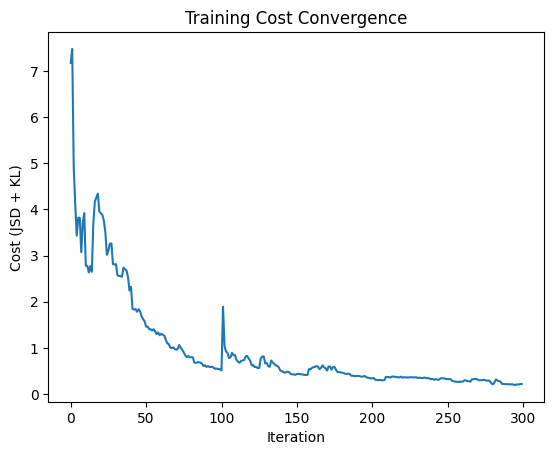

In [139]:

# --- 6. Training (Custom Gradient Descent) ---
# Replicating the custom loop from the old notebook which used perturbation

MAX_ITER = 300 # Tuned for performance/speed
LEARNING_RATE = 0.01
PERTURBATION = 0.1

params = np.random.uniform(0, 2*np.pi, len(theta_params))
history = []

print("Starting training...")
for i in range(MAX_ITER):
    current_cost = cost_function(params)
    history.append(current_cost)
    
    if i % 10 == 0:
        print(f"Iter {i}/{MAX_ITER} - Cost: {current_cost:.4f}")
        
    # SPSA-like step
    delta = np.random.choice([-1, 1], size=len(params)) * PERTURBATION
    
    # We already have current cost, need perturbed costs? 
    # The original notebook computed cost_plus and cost_minus.
    # Let's strictly follow that logic.
    
    cost_plus = cost_function(params + delta)
    cost_minus = cost_function(params - delta)
    
    gradient = (cost_plus - cost_minus) / (2 * delta)
    params = params - LEARNING_RATE * gradient

print("Training Complete.")
plt.plot(history)
plt.title("Training Cost Convergence")
plt.xlabel("Iteration")
plt.ylabel("Cost (JSD + KL)")
plt.show()


Scanning thresholds...

=== FINAL RESULTS (PCA-QCBM Pure) ===
Best F1 Score: 0.7061 at Threshold 0.000599
Accuracy:      0.9852
Precision:     0.6753
Recall:        0.7398
ROC-AUC:       0.9231


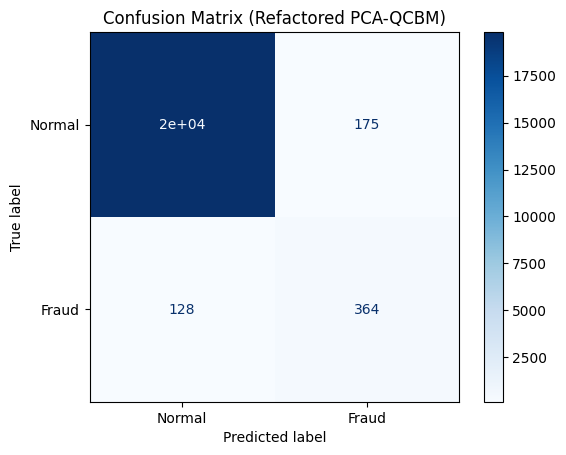

In [140]:

# --- 7. Evaluation & Anomaly Detection ---

# 1. Get Final Learned Distribution
final_probs = get_qcbm_probs(params, qc, theta_params, simulator)
final_probs_2d = final_probs.reshape(GRID_SIZE, GRID_SIZE)

# 2. Compute Likelihoods for Test Data
# Map each sample (x,y) bin to its probability in the learned distribution
likelihoods = final_probs_2d[x_bins, y_bins] # Access by [row_idx, col_idx] -> [x_bin, y_bin] (Matches histogram2d)

# 3. Adaptive Thresholding
thresholds = np.linspace(likelihoods.min(), likelihoods.max(), 200)
best_f1 = 0
best_thresh = 0
best_results = {}

print("Scanning thresholds...")
for t in thresholds:
    # Anomalies are LOW probability (Likelihood < Threshold)
    preds = (likelihoods < t).astype(int)
    
    f1 = f1_score(labels, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t
        best_results = {
            'Precision': precision_score(labels, preds, zero_division=0),
            'Recall': recall_score(labels, preds, zero_division=0),
            'F1': f1,
            'AUC': roc_auc_score(labels, 1 - likelihoods),
            'Accuracy': accuracy_score(labels, preds)
            # Note: AUC expects higher scores for positive class (anomalies). 
            # Since likelihood is low for anomalies, we compare against (1-likelihood) or (-likelihood).
        }

print("\n=== FINAL RESULTS (PCA-QCBM Pure) ===")
print(f"Best F1 Score: {best_f1:.4f} at Threshold {best_thresh:.6f}")
print(f"Accuracy:      {best_results['Accuracy']:.4f}")
print(f"Precision:     {best_results['Precision']:.4f}")
print(f"Recall:        {best_results['Recall']:.4f}")
print(f"ROC-AUC:       {best_results['AUC']:.4f}")

# Confusion Matrix
final_preds = (likelihoods < best_thresh).astype(int)
cm = confusion_matrix(labels, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Refactored PCA-QCBM)")
plt.show()
